# PaddleOCR 3.0 테스트

PaddleOCR 3.0은 2025년 10월에 출시된 버전입니다.
<img src="https://raw.githubusercontent.com/PaddlePaddle/PaddleOCR/main/docs/images/Banner.png" alt="PaddleOCR Banner" />


## 주요 기능

| 기능 | 설명 |
|------|------|
| PP-OCRv5 | 109개 언어 지원, 단일 모델로 다국어 인식 |
| PP-StructureV3 | 문서 레이아웃 분석, 테이블 인식, Markdown 변환 |
| PaddleOCR-VL | 0.9B VLM 기반 문서 파싱 |

In [ ]:
# CUDA 버전 확인
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


In [ ]:
# 설치

# GPU 버전 (Colab에서 런타임 > 런타임 유형 변경 > GPU 선택)
# !python -m pip install paddlepaddle-gpu -i https://www.paddlepaddle.org.cn/packages/stable/cu126/

# CPU 버전 (GPU가 없는 환경에서 사용)
! python -m pip install paddlepaddle==3.2.2 -i https://www.paddlepaddle.org.cn/packages/stable/cpu/
! pip install "paddleocr[all]"

Looking in indexes: https://www.paddlepaddle.org.cn/packages/stable/cpu/


In [ ]:
# 한글 폰트 설치 (결과 시각화용)
!apt-get install -y fonts-nanum > /dev/null 2>&1

import matplotlib.pyplot as plt
from matplotlib import font_manager

# 폰트 직접 등록
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_manager.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

print("폰트 설치 완료")

폰트 설치 완료


## 0. 테스트 이미지 다운로드

한글 OCR 테스트를 위한 샘플 이미지를 다운로드합니다.

--2026-02-22 02:41:33--  https://raw.githubusercontent.com/yunwoong7/toy_datasets/main/image/kor_ocr_test_image_1.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 140174 (137K) [image/jpeg]
Saving to: ‘assets/images/test_image_1.jpg’

assets/images/test_ 100%[===================>] 136.89K  --.-KB/s    in 0.01s   

2026-02-22 02:41:33 (10.7 MB/s) - ‘assets/images/test_image_1.jpg’ saved [140174/140174]

--2026-02-22 02:41:33--  https://raw.githubusercontent.com/yunwoong7/toy_datasets/main/image/kor_ocr_test_image_3.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sen

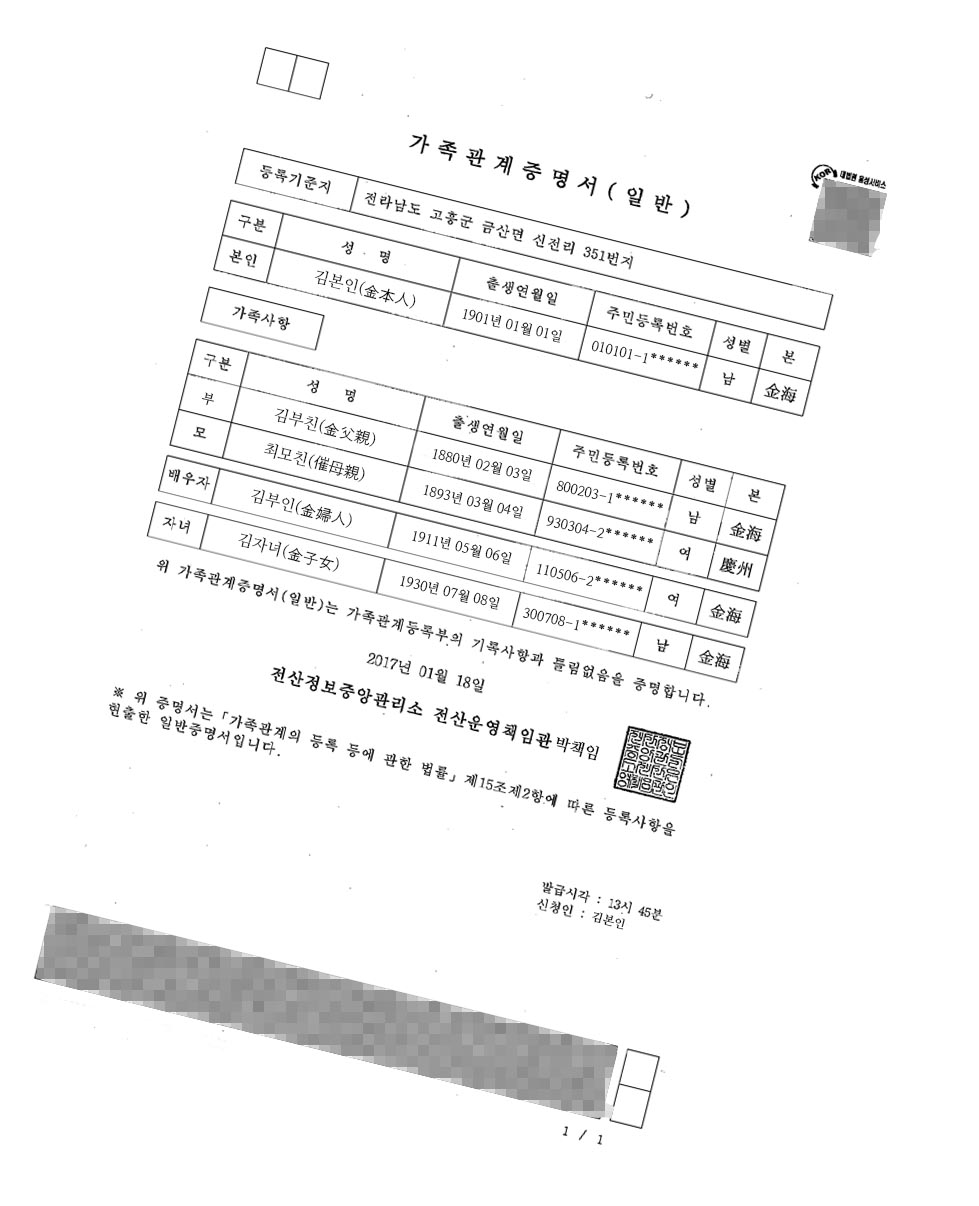


테스트 이미지 3:


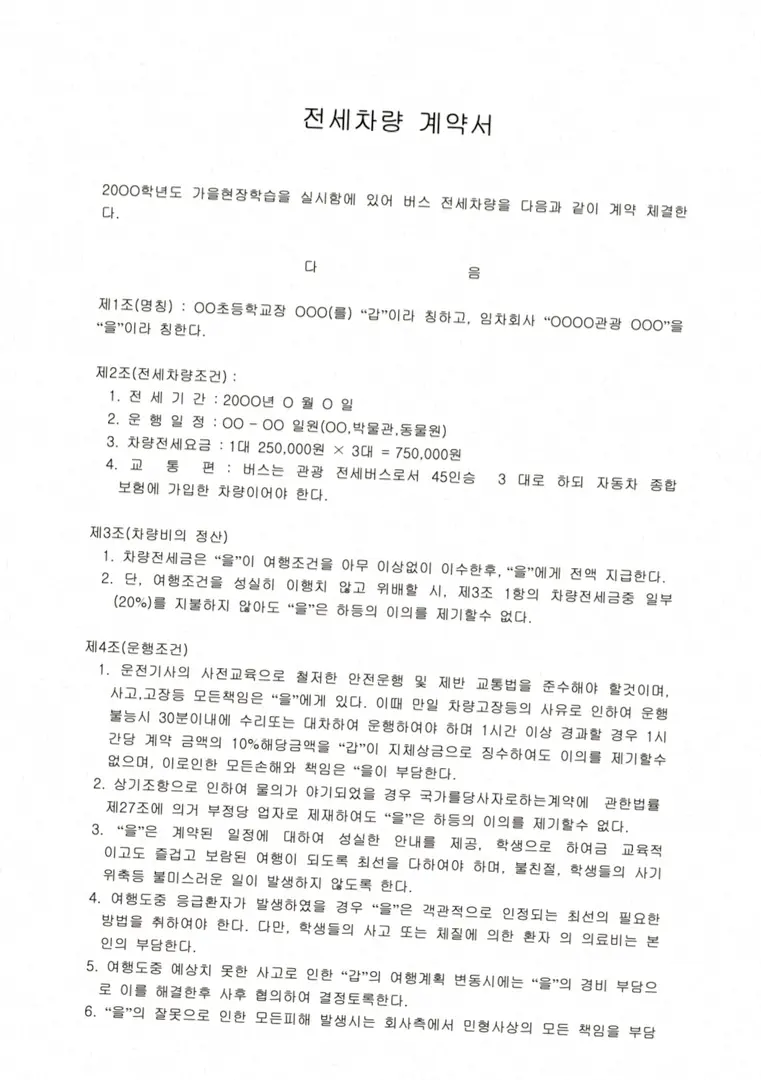


테스트 이미지 4:


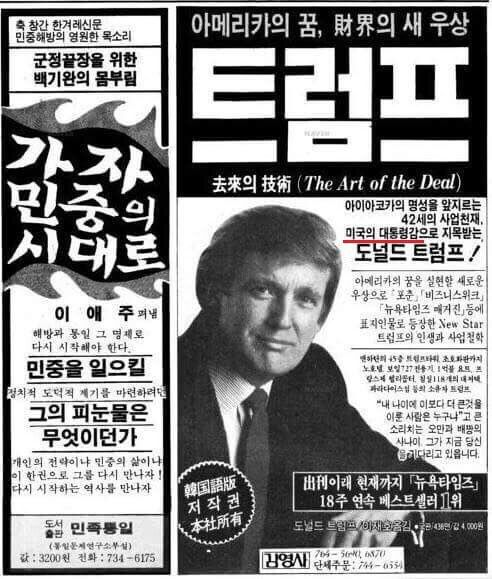

In [ ]:
# 2. 테스트 이미지 다운로드
!mkdir -p assets/images

!wget -O assets/images/test_image_1.jpg "https://raw.githubusercontent.com/yunwoong7/toy_datasets/main/image/kor_ocr_test_image_1.jpg"
!wget -O assets/images/test_image_3.jpg "https://raw.githubusercontent.com/yunwoong7/toy_datasets/main/image/kor_ocr_test_image_3.jpg"
!wget -O assets/images/test_image_4.jpg "https://raw.githubusercontent.com/yunwoong7/toy_datasets/main/image/kor_ocr_test_image_4.jpg"

# 이미지 확인
from IPython.display import Image, display
print("테스트 이미지 1:")
display(Image(filename="assets/images/test_image_1.jpg", width=400))
print("\n테스트 이미지 3:")
display(Image(filename="assets/images/test_image_3.jpg", width=400))
print("\n테스트 이미지 4:")
display(Image(filename="assets/images/test_image_4.jpg", width=400))

## 1. PP-OCRv5 - 텍스트 인식

PP-OCRv5는 PaddleOCR 3.0의 핵심 OCR 엔진입니다.

### 주요 특징
- 단일 모델로 109개 언어 지원 (한글, 영어, 중국어, 일본어 등)
- 모델 크기 2M으로 경량화
- 이전 버전 대비 정확도 13% 향상
- 다국어 혼합 문서도 자동 인식

### 파라미터 설명
| 파라미터 | 설명 |
|----------|------|
| `lang` | 결과 이미지에 표시할 폰트 언어. `korean` 지정 시 한글 폰트 다운로드 |
| `use_doc_orientation_classify` | 문서 방향 자동 보정. False로 비활성화하면 속도 향상 |
| `use_doc_unwarping` | 문서 왜곡 보정. 스캔 문서에 유용 |
| `use_textline_orientation` | 텍스트 라인 방향 감지 |

In [ ]:
from paddleocr import PaddleOCR
import os

ocr_v5 = PaddleOCR(
    lang="korean",
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_textline_orientation=False
)

test_images = [
    "assets/images/test_image_1.jpg",
    "assets/images/test_image_3.jpg",
    "assets/images/test_image_4.jpg"
]

for img_path in test_images:
    print(f"\n{'='*50}")
    print(f"이미지: {img_path}")
    print('='*50)

    img_name = os.path.basename(img_path).split('.')[0]
    output_dir = f"output/pp_ocrv5/{img_name}"

    result = ocr_v5.predict(input=img_path)

    for res in result:
        res.print()
        res.save_to_img(output_dir)
        res.save_to_json(output_dir)

Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-OCRv5_server_det`.
Creating model: ('korean_PP-OCRv5_mobile_rec', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/korean_PP-OCRv5_mobile_rec`.



이미지: assets/images/test_image_1.jpg


{'res': {'input_path': 'assets/images/test_image_1.jpg', 'page_index': None, 'model_settings': {'use_doc_preprocessor': False, 'use_textline_orientation': False}, 'dt_polys': array([[[ 411,  126],
        ...,
        [ 405,  150]],

       ...,

       [[ 560, 1119],
        ...,
        [ 555, 1137]]], dtype=int16), 'text_det_params': {'limit_side_len': 64, 'limit_type': 'min', 'thresh': 0.3, 'max_side_limit': 4000, 'box_thresh': 0.6, 'unclip_ratio': 1.5}, 'text_type': 'general', 'textline_orientation_angles': array([-1, ..., -1]), 'text_rec_score_thresh': 0.0, 'return_word_box': False, 'rec_texts': ['가족관계증명서(일반)', '등록기준지', ' 용경비스', '전라남도 고흥군 금산면신전리 351번지', '구분', '성명', '본인', '김본인(스)', '출생연월일', '가족사항', '1901년01월01일', '주민등록번호', '010101-1******', '성별', '구분', '본', '성명', '남', '', '부', '김부친()', '출생연월일', '모', '최모친()', '1880년 02월 03일', '주민등록번호', '배우자', '성별', '김부인()', '1893년 03월 04일', '800203–1******', '본', '자녀', '930304-2******', '남', '1911년 05월 06일', '', '김자녀()', '여', '위가족관계증명서(일반)는 가족관계등록부


이미지: assets/images/test_image_3.jpg


{'res': {'input_path': 'assets/images/test_image_3.jpg', 'page_index': None, 'model_settings': {'use_doc_preprocessor': False, 'use_textline_orientation': False}, 'dt_polys': array([[[ 302,  102],
        ...,
        [ 301,  129]],

       ...,

       [[  82, 1000],
        ...,
        [  81, 1018]]], dtype=int16), 'text_det_params': {'limit_side_len': 64, 'limit_type': 'min', 'thresh': 0.3, 'max_side_limit': 4000, 'box_thresh': 0.6, 'unclip_ratio': 1.5}, 'text_type': 'general', 'textline_orientation_angles': array([-1, ..., -1]), 'text_rec_score_thresh': 0.0, 'return_word_box': False, 'rec_texts': ['전세차량 계약서', '2000학년도 가을현장학습을 실시항에 있어 버스 전세차량을 다음과 같이 계약 체결한', '다.', '다', '음', '제1조(명칭): 00초등학교장00이(를)“갑"이라 칭하고,임차회사“0000관광 000"을', '“을"이라 칭한다.', '제2조(전세차량조건):', '1.전세기간:2000년0월0일', '2.운 행 일 정: 00-00일원(00.박울관.동물원)', '3. 차량전세요금 : 1대250,000원×3대 = 750,000원', '4. 교 통 편: 버스는 관광 전세버스로서 45인승 3 대로 하되 자동차 종합', '보험에 가입한차량이어야 한다', '제3조(차량비의정산)', '1.차량전세금은“을"이 여행조건을아무 이상없이 이수한후,“을"에게 전액 지급한다', '2. 단 


이미지: assets/images/test_image_4.jpg


{'res': {'input_path': 'assets/images/test_image_4.jpg', 'page_index': None, 'model_settings': {'use_doc_preprocessor': False, 'use_textline_orientation': False}, 'dt_polys': array([[[ 12,  17],
        ...,
        [ 12,  31]],

       ...,

       [[312, 558],
        ...,
        [312, 571]]], dtype=int16), 'text_det_params': {'limit_side_len': 64, 'limit_type': 'min', 'thresh': 0.3, 'max_side_limit': 4000, 'box_thresh': 0.6, 'unclip_ratio': 1.5}, 'text_type': 'general', 'textline_orientation_angles': array([-1, ..., -1]), 'text_rec_score_thresh': 0.0, 'return_word_box': False, 'rec_texts': ['축창간 한겨레신문', '아메리카의꿈의새우상', '민중해방의영원한목소리', '트럼프', '군정끌장을위한', '백기완의몸부림', '갓자', '민중의', '의 (The Art of the Deal)', '아이아코카의 명성을 앞지르는', '시대로', '42세의 사업천재', '미국의 대통령감으로지목받는', '도널드트럼프/', '아에리카의 꿈을 실현할 새로운', '우상으로포준비즈니스위크', '이애주퍼념', '[뉴욕타임즈 매거진등에', '표지인물로 등장한 New Star', '해방과 통일 그 명제로', '다시 시작해야 한다', '트럽프의 인생과 사업절학', '민중을일으킬', '하의타지', '노분.보일727전용기 1억를 요트,보', '닥스제병리용터링을1게의대저해', '평치적 도력적 제기를 마련하려면', '파라다이스럼

### 결과 확인

원본 이미지에 인식된 텍스트 영역을 박스로 표시하고, 오른쪽에 인식된 텍스트 목록을 출력합니다.

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image as PILImage
import json
import os

for img_name in ["test_image_1", "test_image_3", "test_image_4"]:
    output_dir = f"output/pp_ocrv5/{img_name}"

    if os.path.exists(output_dir):
        # 결과 이미지 찾기
        result_img = f"{output_dir}/{img_name}_ocr_res_img.jpg"

        # JSON에서 텍스트 추출
        json_path = f"{output_dir}/{img_name}_res.json"
        texts = []
        if os.path.exists(json_path):
            with open(json_path, "r", encoding="utf-8") as f:
                data = json.load(f)
                if "rec_texts" in data:
                    texts = data["rec_texts"]

        # 이미지 출력
        if os.path.exists(result_img):
            img = PILImage.open(result_img)
            plt.figure(figsize=(14, 10))
            plt.imshow(img)
            plt.title(f"{img_name}", fontsize=16, fontweight='bold')
            plt.axis('off')
            plt.show()

        # 텍스트 출력
        print("인식된 텍스트:")
        print("-" * 50)
        for i, t in enumerate(texts, 1):
            print(f"{i}. {t}")
        print("\n")

## 2. PP-StructureV3 - 문서 구조 분석

PP-StructureV3는 문서의 레이아웃을 분석하고 구조화된 데이터로 변환합니다.

### 주요 기능
- 문서 레이아웃 분석 (텍스트, 표, 이미지, 수식 등 영역 구분)
- 테이블 인식 및 구조화
- Markdown/JSON 형식으로 변환
- 복잡한 PDF 문서 파싱

### 파라미터 설명
| 파라미터 | 설명 |
|----------|------|
| `lang` | 출력 폰트 언어. `korean` 지정 시 한글 폰트 다운로드 |
| `use_doc_orientation_classify` | 문서 방향 자동 보정 |
| `use_doc_unwarping` | 문서 왜곡 보정 |

In [ ]:
from paddleocr import PPStructureV3
import os

structure = PPStructureV3(
    lang="korean",
    use_doc_orientation_classify=False,
    use_doc_unwarping=False
)

test_images = [
    "assets/images/test_image_1.jpg",
    "assets/images/test_image_3.jpg",
    "assets/images/test_image_4.jpg"
]

for img_path in test_images:
    print(f"\n{'='*50}")
    print(f"이미지: {img_path}")
    print('='*50)

    img_name = os.path.basename(img_path).split('.')[0]
    output_dir = f"output/pp_structurev3/{img_name}"

    result = structure.predict(input=img_path)

    for res in result:
        res.print()
        res.save_to_img(output_dir)
        res.save_to_json(output_dir)
        res.save_to_markdown(output_dir)

### 결과 확인

PP-StructureV3는 문서의 각 영역(텍스트, 표, 이미지 등)을 감지하고 구조화합니다.

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image as PILImage
import os

for img_name in ["test_image_1", "test_image_3", "test_image_4"]:
    output_dir = f"output/pp_structurev3/{img_name}"

    if os.path.exists(output_dir):
        # 결과 이미지 찾기
        result_img = None
        for f in os.listdir(output_dir):
            if f.endswith(('.png', '.jpg')) and 'res' in f:
                result_img = f"{output_dir}/{f}"
                break

        # 이미지 출력
        if result_img and os.path.exists(result_img):
            img = PILImage.open(result_img)
            plt.figure(figsize=(14, 10))
            plt.imshow(img)
            plt.title(f"{img_name} - PP-StructureV3", fontsize=16, fontweight='bold')
            plt.axis('off')
            plt.show()

        print("\n")

### Markdown 변환 결과

PP-StructureV3는 문서를 Markdown 형식으로 변환합니다. 표는 Markdown 테이블로, 텍스트는 그대로 추출됩니다.

In [ ]:
import os

for img_name in ["test_image_1", "test_image_3", "test_image_4"]:
    output_dir = f"output/pp_structurev3/{img_name}"

    # Markdown 파일 찾기
    md_file = None
    if os.path.exists(output_dir):
        for f in os.listdir(output_dir):
            if f.endswith('.md'):
                md_file = f"{output_dir}/{f}"
                break

    if md_file and os.path.exists(md_file):
        print(f"\n{'='*50}")
        print(f"{img_name} Markdown 결과:")
        print('='*50)
        with open(md_file, "r", encoding="utf-8") as f:
            print(f.read())
        print("\n")

### JSON 결과 확인

JSON에는 각 영역의 좌표, 타입(text, table, figure 등), 인식된 내용이 포함됩니다.

In [ ]:
import json
import os

for img_name in ["test_image_1", "test_image_3", "test_image_4"]:
    output_dir = f"output/pp_structurev3/{img_name}"

    # JSON 파일 찾기
    json_file = None
    if os.path.exists(output_dir):
        for f in os.listdir(output_dir):
            if f.endswith('.json'):
                json_file = f"{output_dir}/{f}"
                break

    if json_file and os.path.exists(json_file):
        print(f"\n{'='*50}")
        print(f"{img_name} 레이아웃 분석 결과:")
        print('='*50)
        with open(json_file, "r", encoding="utf-8") as f:
            data = json.load(f)

            # layout_det_res > boxes에서 영역 정보 추출
            if "layout_det_res" in data and "boxes" in data["layout_det_res"]:
                boxes = data["layout_det_res"]["boxes"]
                print(f"감지된 영역 수: {len(boxes)}")
                print("-" * 30)
                for i, region in enumerate(boxes):
                    label = region.get('label', 'N/A')
                    score = region.get('score', 0)
                    print(f"  {i+1}. {label} (신뢰도: {score:.2f})")
        print("\n")

## PaddleOCR-VL - VLM 기반 문서 파싱

PaddleOCR-VL은 0.9B 파라미터의 Vision-Language Model(VLM)을 기반으로 한 문서 파싱 모델입니다.

### 주요 특징
- 0.9B 경량 VLM으로 빠른 추론 속도
- 109개 언어 자동 인식 (별도 언어 설정 불필요)
- 복잡한 요소 인식 (텍스트, 표, 수식, 차트 등)
- 손글씨, 역사 문서 등 다양한 문서 타입 지원
- Markdown 형식으로 변환

### PP-StructureV3와의 차이점
| 구분 | PP-StructureV3 | PaddleOCR-VL |
|------|----------------|--------------|
| 방식 | 파이프라인 기반 (감지 → 인식) | End-to-End VLM |
| 모델 크기 | 여러 모델 조합 | 단일 0.9B 모델 |
| 언어 설정 | `lang` 파라미터 필요 | 자동 인식 |
| 장점 | 정확한 좌표 정보 | 문맥 이해, 복잡한 레이아웃 처리 |

In [ ]:
from paddleocr import PaddleOCRVL
import os

ocr_vl = PaddleOCRVL()

test_images = [
    "assets/images/test_image_1.jpg",
    "assets/images/test_image_3.jpg",
    "assets/images/test_image_4.jpg"
]

for img_path in test_images:
    print(f"\n{'='*50}")
    print(f"이미지: {img_path}")
    print('='*50)

    img_name = os.path.basename(img_path).split('.')[0]
    output_dir = f"output/paddleocr_vl/{img_name}"

    result = ocr_vl.predict(input=img_path)

    for res in result:
        res.print()
        res.save_to_img(output_dir)
        res.save_to_json(output_dir)
        res.save_to_markdown(output_dir)

### 결과 확인

PaddleOCR-VL은 문서 전체를 이해하고 구조화된 형태로 변환합니다.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image as PILImage
from matplotlib import font_manager
import os
import json
import textwrap

# 한글 폰트 설정
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_manager.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 레이블별 색상 지정 (진한 톤)
label_colors = {
    'table': '#C0392B',
    'text': '#1E8449',
    'header': '#1A5276',
    'image': '#117A65',
    'formula': '#B7950B',
    'figure': '#6C3483'
}

for img_name in ["test_image_1", "test_image_3", "test_image_4"]:
    output_dir = f"output/paddleocr_vl/{img_name}"
    img_path = f"assets/images/{img_name}.jpg"

    if os.path.exists(output_dir) and os.path.exists(img_path):
        # JSON 파일 찾기
        json_file = None
        for f in os.listdir(output_dir):
            if f.endswith('.json'):
                json_file = f"{output_dir}/{f}"
                break

        if json_file:
            with open(json_file, "r", encoding="utf-8") as f:
                data = json.load(f)

            # 이미지 로드
            img = PILImage.open(img_path)

            fig, axes = plt.subplots(1, 2, figsize=(20, 12))

            # 왼쪽: 원본 이미지
            axes[0].imshow(img)
            axes[0].set_title(f"{img_name} - 원본", fontsize=14, fontweight='bold')
            axes[0].axis('off')

            # 오른쪽: 인식 결과 오버레이
            axes[1].imshow(img)

            # parsing_res_list에서 블록 그리기
            if "parsing_res_list" in data:
                for block in data["parsing_res_list"]:
                    bbox = block.get("block_bbox", [])
                    label = block.get("block_label", "")
                    content = block.get("block_content", "")

                    if len(bbox) == 4:
                        x1, y1, x2, y2 = bbox
                        width = x2 - x1
                        height = y2 - y1

                        color = label_colors.get(label, '#333333')

                        # 흰색 배경으로 원본 가리기
                        rect_bg = patches.Rectangle(
                            (x1, y1), width, height,
                            linewidth=0,
                            facecolor='white',
                            alpha=0.95
                        )
                        axes[1].add_patch(rect_bg)

                        # 테두리 박스
                        rect_border = patches.Rectangle(
                            (x1, y1), width, height,
                            linewidth=2,
                            edgecolor=color,
                            facecolor='none'
                        )
                        axes[1].add_patch(rect_border)

                        # 라벨 표시
                        axes[1].text(x1, y1 - 5, f"{label}",
                                fontsize=10, color='white', fontweight='bold',
                                bbox=dict(boxstyle='round,pad=0.2', facecolor=color, alpha=0.9))

                        # 내용 오버레이
                        if content:
                            if label == 'table':
                                display_text = "[TABLE]"
                                fontsize = 11
                            else:
                                # 박스 너비에 맞춰 줄바꿈
                                chars_per_line = max(int(width / 12), 10)
                                wrapped = textwrap.fill(content, width=chars_per_line)
                                display_text = wrapped
                                fontsize = 9

                            axes[1].text(x1 + 5, y1 + 15, display_text,
                                    fontsize=fontsize, color=color, fontweight='bold',
                                    verticalalignment='top')

            axes[1].set_title(f"{img_name} - 인식 결과", fontsize=14, fontweight='bold')
            axes[1].axis('off')

            plt.tight_layout()
            plt.show()

        print("\n")

### Markdown 변환 결과

PaddleOCR-VL은 문서 내용을 Markdown 형식으로 변환합니다. 표, 수식 등도 Markdown 문법으로 표현됩니다.

In [ ]:
from IPython.display import display, HTML
import os

for img_name in ["test_image_1", "test_image_3", "test_image_4"]:
    output_dir = f"output/paddleocr_vl/{img_name}"

    # Markdown 파일 찾기
    md_file = None
    if os.path.exists(output_dir):
        for f in os.listdir(output_dir):
            if f.endswith('.md'):
                md_file = f"{output_dir}/{f}"
                break

    if md_file and os.path.exists(md_file):
        print(f"\n{'='*50}")
        print(f"{img_name} 결과:")
        print('='*50)
        with open(md_file, "r", encoding="utf-8") as f:
            content = f.read()
            # HTML 테이블이면 렌더링
            if '<table' in content:
                display(HTML(content))
            else:
                print(content)
        print("\n")

### JSON 결과 확인

In [ ]:
import json
import os

for img_name in ["test_image_1", "test_image_3", "test_image_4"]:
    output_dir = f"output/paddleocr_vl/{img_name}"

    # JSON 파일 찾기
    json_file = None
    if os.path.exists(output_dir):
        for f in os.listdir(output_dir):
            if f.endswith('.json'):
                json_file = f"{output_dir}/{f}"
                break

    if json_file and os.path.exists(json_file):
        print(f"\n{'='*50}")
        print(f"{img_name} JSON 구조:")
        print('='*50)
        with open(json_file, "r", encoding="utf-8") as f:
            data = json.load(f)
            print(f"키 목록: {list(data.keys())}")
            print(json.dumps(data, indent=2, ensure_ascii=False)[:1500])
        print("\n")